In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("data/posture_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1200, 52)


,kp_0_x,kp_0_y,kp_0_conf,kp_1_x,kp_1_y,kp_1_conf,kp_2_x,kp_2_y,kp_2_conf,kp_3_x,...,kp_14_x,kp_14_y,kp_14_conf,kp_15_x,kp_15_y,kp_15_conf,kp_16_x,kp_16_y,kp_16_conf,label
0,343.805450,97.815353,0.998584,362.729645,81.259018,0.994111,326.274261,80.348709,0.995496,385.519226,...,217.092377,471.144897,0.013316,512.135437,480.0,0.000572,256.193298,458.622040,0.000725,0
1,343.262299,97.681870,0.998581,362.659393,81.755783,0.994333,325.825378,80.456268,0.995307,386.043060,...,214.983704,468.110901,0.013181,508.664490,480.0,0.000600,253.522995,456.119690,0.000745,0
2,343.344025,97.368561,0.998565,362.434387,81.149429,0.994340,326.011108,80.224808,0.995203,385.761810,...,215.863922,467.346436,0.012333,514.368591,480.0,0.000565,256.654999,454.691101,0.000699,0
3,344.185120,96.994186,0.998589,363.452240,81.067322,0.994279,327.037384,79.778397,0.995351,386.280151,...,215.705658,468.048218,0.011519,516.525391,480.0,0.000528,258.874573,456.763519,0.000650,0
4,344.324554,97.390564,0.998564,363.042206,80.942993,0.994060,326.951111,80.184937,0.995359,385.414917,...,214.702240,470.366241,0.012500,512.321899,480.0,0.000561,255.905579,457.252655,0.000688,0


In [32]:
# check shape and class balance
print(f"Shape: {df.shape}")
print("\nClass balance:")
print(df['label'].value_counts().rename({0: 'good', 1: 'slouch'}))

# check average confidence per keypoint to identify useless ones
conf_cols = [f'kp_{i}_conf' for i in range(17)]
print("\nAverage confidence per keypoint:")
for i,col in enumerate(conf_cols):
    print(f" kp_{i} ({col}): {df[col].mean():.4f}")


Shape: (1200, 52)

Class balance:
label
good      690
slouch    510
Name: count, dtype: int64

Average confidence per keypoint:
 kp_0 (kp_0_conf): 0.9967
 kp_1 (kp_1_conf): 0.9897
 kp_2 (kp_2_conf): 0.9905
 kp_3 (kp_3_conf): 0.8866
 kp_4 (kp_4_conf): 0.8780
 kp_5 (kp_5_conf): 0.9919
 kp_6 (kp_6_conf): 0.9953
 kp_7 (kp_7_conf): 0.8942
 kp_8 (kp_8_conf): 0.9347
 kp_9 (kp_9_conf): 0.7539
 kp_10 (kp_10_conf): 0.8078
 kp_11 (kp_11_conf): 0.5903
 kp_12 (kp_12_conf): 0.6420
 kp_13 (kp_13_conf): 0.0148
 kp_14 (kp_14_conf): 0.0171
 kp_15 (kp_15_conf): 0.0016
 kp_16 (kp_16_conf): 0.0017


In [33]:
# dropping low confidence values

drop_kps =[13,14,15,16]
drop_cols = [f'kp_{i}_{v}' for i in drop_kps for v in ['x','y','conf']]

df = df.drop(columns=drop_cols)
print(f"Shape after dropping: {df.shape}")
print(f"Dropped columns: {drop_cols}")

Shape after dropping: (1200, 40)
Dropped columns: ['kp_13_x', 'kp_13_y', 'kp_13_conf', 'kp_14_x', 'kp_14_y', 'kp_14_conf', 'kp_15_x', 'kp_15_y', 'kp_15_conf', 'kp_16_x', 'kp_16_y', 'kp_16_conf']


In [34]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"Training sample: {len(X_train)}")
print(f"Test sample: {len(X_test)}")

Training sample: 960
Test sample: 240


In [35]:
model = MLPClassifier(hidden_layer_sizes=(64,32), max_iter = 500, random_state = 42, verbose = True)
model.fit(X_train, y_train)
print("Training done.")

Iteration 1, loss = 19.80533045
Iteration 2, loss = 11.57880052
Iteration 3, loss = 9.61684485
Iteration 4, loss = 8.05751777
Iteration 5, loss = 3.44763756
Iteration 6, loss = 2.86722046
Iteration 7, loss = 1.84557881
Iteration 8, loss = 1.69971355
Iteration 9, loss = 1.15451431
Iteration 10, loss = 0.80061816
Iteration 11, loss = 0.62423595
Iteration 12, loss = 0.51370485
Iteration 13, loss = 0.40102760
Iteration 14, loss = 0.33429438
Iteration 15, loss = 0.27398531
Iteration 16, loss = 0.25220761
Iteration 17, loss = 0.24083919
Iteration 18, loss = 0.23337794
Iteration 19, loss = 0.20377350
Iteration 20, loss = 0.19599985
Iteration 21, loss = 0.18856191
Iteration 22, loss = 0.17905523
Iteration 23, loss = 0.17205978
Iteration 24, loss = 0.16666957
Iteration 25, loss = 0.17082109
Iteration 26, loss = 0.17059228
Iteration 27, loss = 0.15773355
Iteration 28, loss = 0.17937301
Iteration 29, loss = 0.16047187
Iteration 30, loss = 0.16149907
Iteration 31, loss = 0.15433802
Iteration 32, l

Accuracy :  0.9958

Classification Report:
              precision    recall  f1-score   support

        good       0.99      1.00      1.00       141
      slouch       1.00      0.99      0.99        99

    accuracy                           1.00       240
   macro avg       1.00      0.99      1.00       240
weighted avg       1.00      1.00      1.00       240



<function matplotlib.pyplot.show(close=None, block=None)>

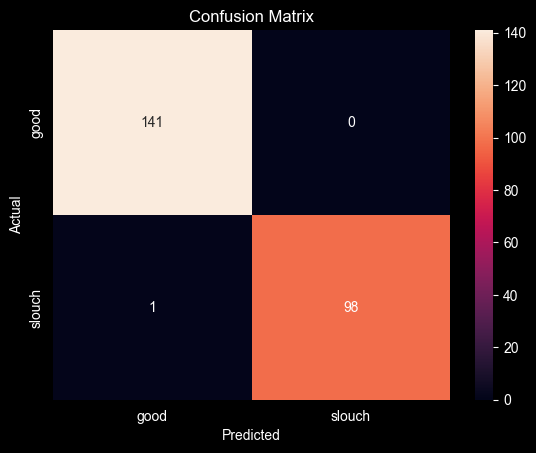

In [36]:
y_pred = model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test,y_pred): .4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['good', 'slouch']))

# confusion matrix

cm= confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels = ['good','slouch'],yticklabels=['good','slouch'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show

In [37]:
# saving the model

joblib.dump(model, 'model.pkl')
print("Model saved to model.pkl")

Model saved to model.pkl
